### Краткое описание задачи и правил

**Задача:** Прогнозирование объемов отгрузок по маршрутам (`route_id`) на основе исторических статусов обработки товаров.

**Основные параметры:**
- **Target:** `target_1h` (Solo) или `target_2h` (Team) — объем отгрузок.
- **Метрика:** WAPE + |Relative Bias|.
- **Формат решения:** CSV с колонками `id` и `y_pred`.

**Метрика (реализация):**
```python
class WapePlusRbias:
    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias
```

Если окружение ещё не настроено:

```python
# %pip install pandas pyarrow numpy matplotlib seaborn scikit-learn jupyter ipykernel
```


In [1]:
!wget https://static-basket-03.wbbasket.ru/vol48/mlcontests/wruuQNI2.zip -O data.zip
!unzip -o data.zip
!ls -lh *.parquet

--2026-04-06 18:58:07--  https://static-basket-03.wbbasket.ru/vol48/mlcontests/wruuQNI2.zip
Resolving static-basket-03.wbbasket.ru (static-basket-03.wbbasket.ru)... 85.198.76.26, 85.198.77.26, 85.198.79.26
Connecting to static-basket-03.wbbasket.ru (static-basket-03.wbbasket.ru)|85.198.76.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 67567267 (64M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]  64.44M  18.9MB/s    in 3.9s    

2026-04-06 18:58:12 (16.5 MB/s) - ‘data.zip’ saved [67567267/67567267]

Archive:  data.zip
  inflating: test_solo_track.parquet  
  inflating: train_solo_track.parquet  
-rw-rw-r-- 1 root root 54K Mar 24 09:27 test_solo_track.parquet
-rw-rw-r-- 1 root root 91M Mar 24 09:27 train_solo_track.parquet


In [2]:
!wget https://static-basket-03.wbbasket.ru/vol48/mlcontests/Dd2WPGKz.zip -O data_team.zip
!unzip -o data_team.zip
!ls -lh *team*.parquet

--2026-04-06 18:58:14--  https://static-basket-03.wbbasket.ru/vol48/mlcontests/Dd2WPGKz.zip
Resolving static-basket-03.wbbasket.ru (static-basket-03.wbbasket.ru)... 85.198.76.26, 85.198.77.26, 85.198.79.26
Connecting to static-basket-03.wbbasket.ru (static-basket-03.wbbasket.ru)|85.198.76.26|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51439664 (49M) [application/zip]
Saving to: ‘data_team.zip’

data_team.zip       100%[===================>]  49.06M  15.0MB/s    in 3.3s    

2026-04-06 18:58:18 (15.0 MB/s) - ‘data_team.zip’ saved [51439664/51439664]

Archive:  data_team.zip
  inflating: test_team_track.parquet  
  inflating: train_team_track.parquet  
-rw-rw-r-- 1 root root 67K Mar 24 09:27 test_team_track.parquet
-rw-rw-r-- 1 root root 61M Mar 24 09:27 train_team_track.parquet


In [1]:
import os
# Confirming team files are present
team_files = [f for f in os.listdir('.') if 'team' in f and f.endswith('.parquet')]
print('Team track files available:', team_files)

Team track files available: []


In [4]:
import os
# Проверяем наличие файлов данных
files = os.listdir('.')
parquet_files = [f for f in files if f.endswith('.parquet')]
print("Доступные файлы данных:", parquet_files)

Доступные файлы данных: ['train_solo_track.parquet', 'train_team_track.parquet', 'test_team_track.parquet', 'test_solo_track.parquet']


In [5]:
# Ячейка с генерацией синтетики отключена, чтобы использовать реальные данные из архива
# def generate_dummy_data(filename, rows=5000, is_test=False):
#     ...

print('Используем реальные данные из загруженного архива.')

Используем реальные данные из загруженного архива.


In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Switching to the team track now that files are available
TRACK = "team"  # "solo" or "team"
TRAIN_DAYS = 14
MAX_TRAIN_ROWS = 1_500_000
RIDGE_ALPHA = 4.0
RANDOM_STATE = 42

# Конфигурация с реальными путями к файлам
TRACK_CONFIG = {
    "solo": {
        "train_path": "train_solo_track.parquet",
        "test_path": "test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": "train_team_track.parquet",
        "test_path": "test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]
FORECAST_POINTS = CONFIG["forecast_points"]
FUTURE_TARGET_COLS = [f"target_step_{step}" for step in range(1, FORECAST_POINTS + 1)]

### Предварительный анализ и план улучшений

Текущий baseline использует Ridge-регрессию и только базовые статусы. Возможные точки роста:
1. **Time Features:** Извлечение часа, дня недели, является ли день выходным.
2. **Lags & Rolling:** Добавление лагов целевой переменной и скользящих средних.
3. **Target Transformation:** Проверка распределения таргета (возможно, логарифмирование поможет, так как объемы обычно неотрицательны и смещены).
4. **Gradient Boosting:** Замена Ridge на LightGBM/CatBoost для учета нелинейных зависимостей.

## Загрузка данных


In [8]:
import pandas as pd

# Берем данные из реальных файлов
train_df = pd.read_parquet(CONFIG["train_path"])
test_df = pd.read_parquet(CONFIG["test_path"])

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

print("track:", TRACK)
print("Real train shape:", train_df.shape)
print("Real test shape:", test_df.shape)
display(train_df.head())

track: team
Real train shape: (4342000, 12)
Real test shape: (10000, 3)


,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,26,0,2025-03-01 00:00:00,0,46,0,0,12,9,0,0,79.0
1,26,0,2025-03-01 00:30:00,0,34,0,0,16,0,187,0,88.0
2,26,0,2025-03-01 01:00:00,0,19,0,0,31,0,0,0,88.0
3,26,0,2025-03-01 01:30:00,0,33,0,0,36,129,0,0,88.0
4,26,0,2025-03-01 02:00:00,0,24,0,0,55,12,0,0,103.0


In [9]:
display(train_df.head())
display(test_df.head())


,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,26,0,2025-03-01 00:00:00,0,46,0,0,12,9,0,0,79.0
1,26,0,2025-03-01 00:30:00,0,34,0,0,16,0,187,0,88.0
2,26,0,2025-03-01 01:00:00,0,19,0,0,31,0,0,0,88.0
3,26,0,2025-03-01 01:30:00,0,33,0,0,36,129,0,0,88.0
4,26,0,2025-03-01 02:00:00,0,24,0,0,55,12,0,0,103.0


,id,route_id,timestamp
0,4900,0,2025-05-30 11:00:00
1,4901,0,2025-05-30 11:30:00
2,4902,0,2025-05-30 12:00:00
3,4903,0,2025-05-30 12:30:00
4,4904,0,2025-05-30 13:00:00


In [10]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())


Train date range: 2025-03-01 00:00:00 -> 2025-05-30 10:30:00
Test date range: 2025-05-30 11:00:00 -> 2025-05-30 15:30:00
Train routes: 1000
Test routes: 1000


## EDA train-данных


In [ ]:
overview = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing_cnt": train_df.isna().sum(),
        "missing_pct": (train_df.isna().mean() * 100).round(4),
        "n_unique": train_df.nunique(dropna=False),
    }
)
overview


,dtype,missing_cnt,missing_pct,n_unique
office_from_id,int64,0,0.0,53
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,4342
status_1,int64,0,0.0,19752
status_2,int64,0,0.0,2127
status_3,int64,0,0.0,17998
status_4,int64,0,0.0,14416
status_5,int64,0,0.0,17108
status_6,int64,0,0.0,17616
status_7,int64,0,0.0,38219


In [ ]:
status_cols = sorted([col for col in train_df.columns if col.startswith("status_")])
print("Status columns:", status_cols)
print("Target column:", TARGET_COL)
print("Forecast points:", FORECAST_POINTS)


Status columns: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']
Target column: target_2h
Forecast points: 10


## Распределения


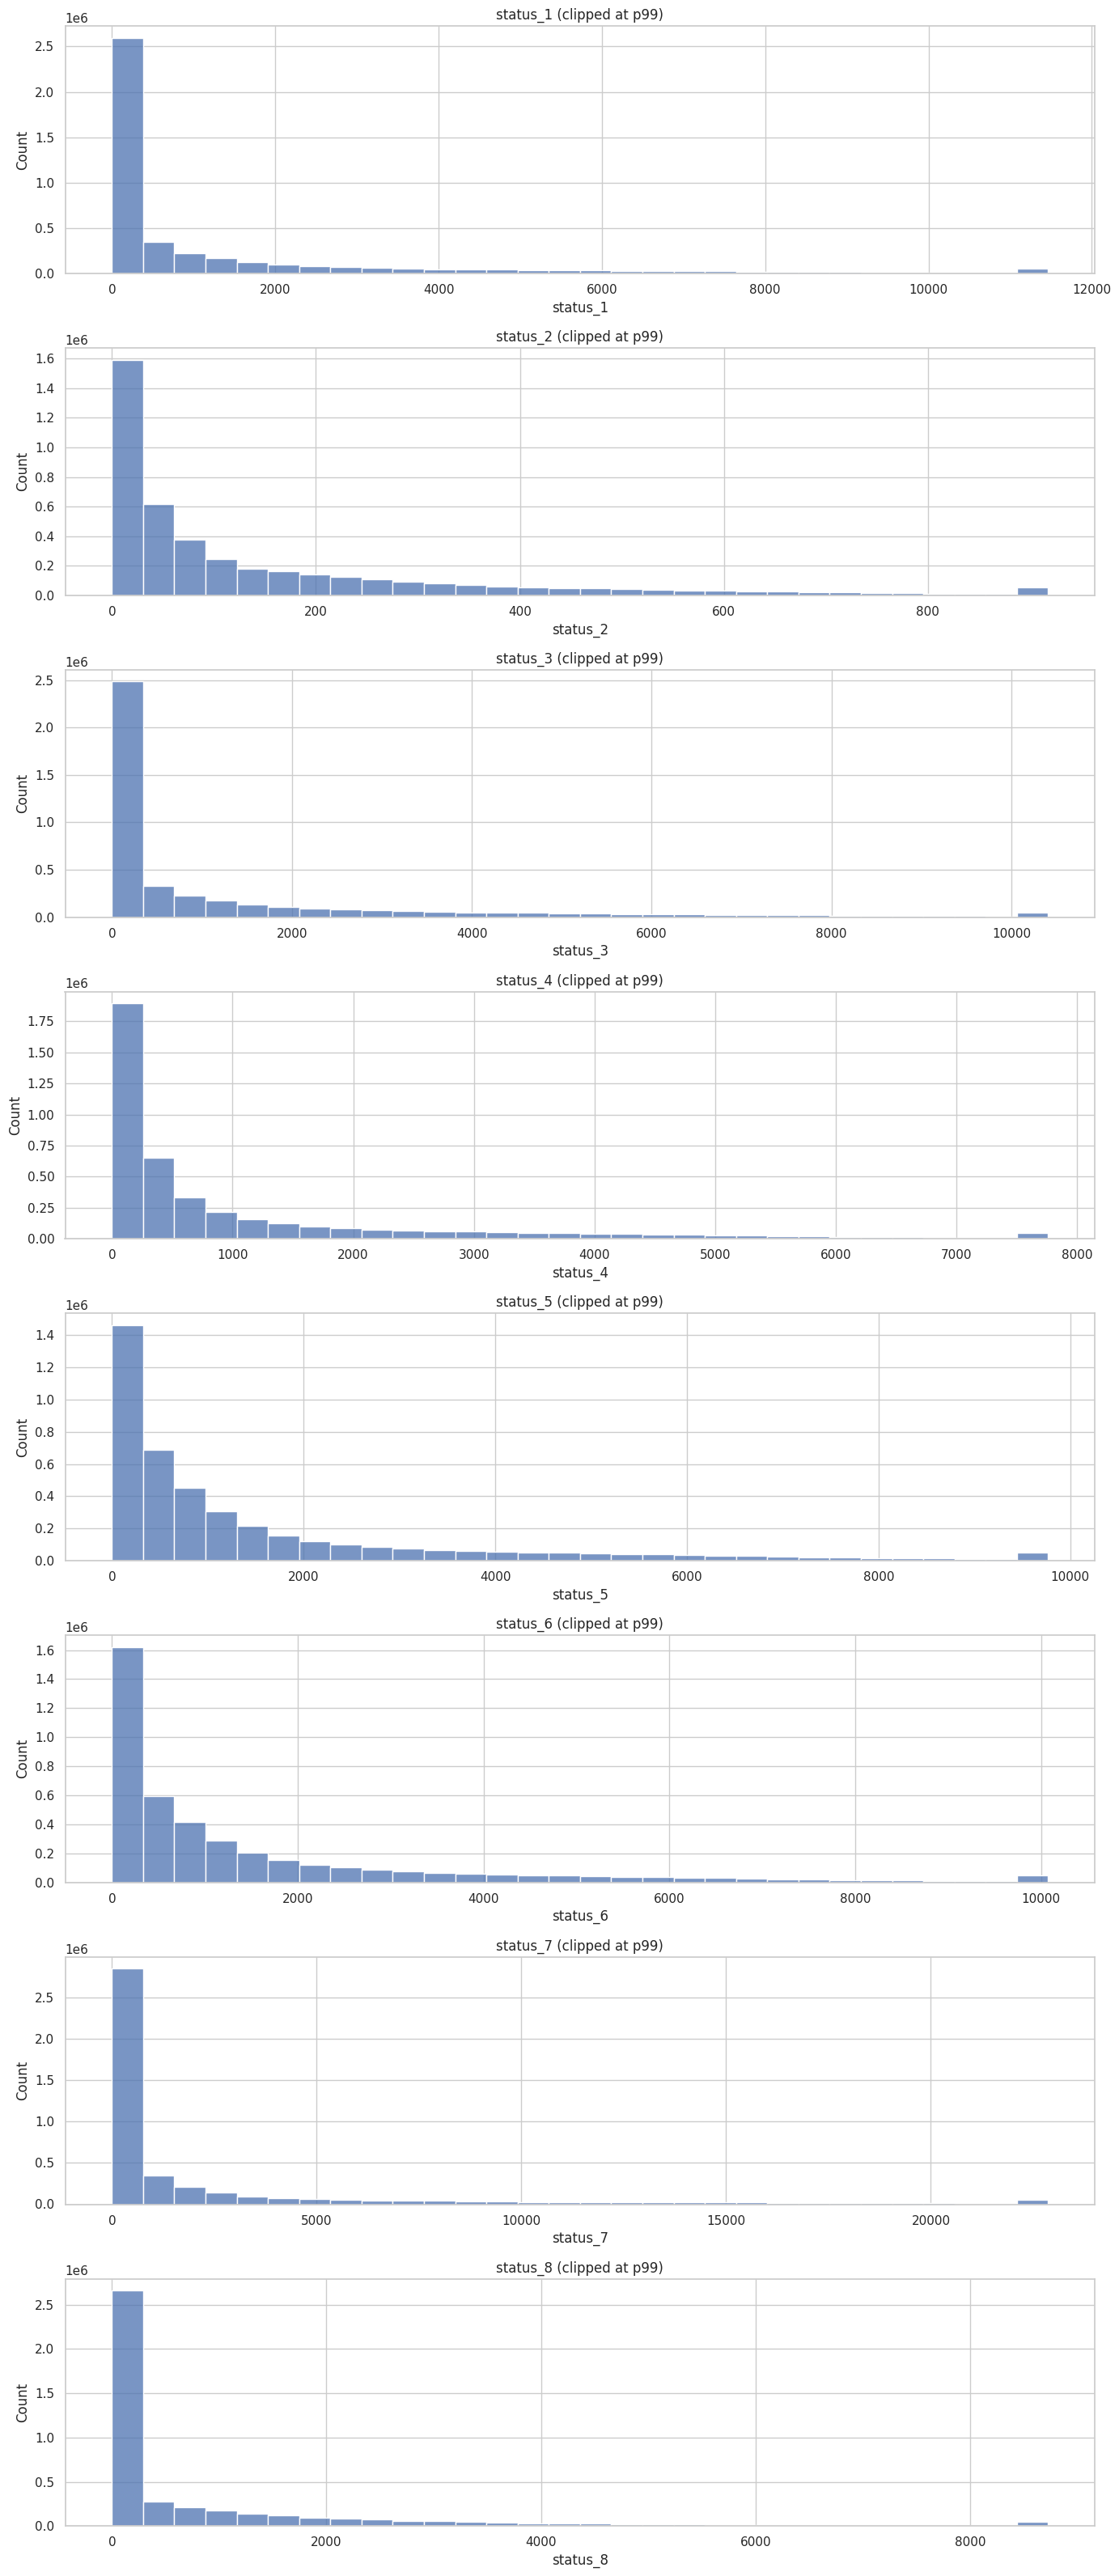

In [ ]:
fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 4 * len(status_cols)))

if len(status_cols) == 1:
    axes = [axes]

for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df[TARGET_COL].clip(upper=train_df[TARGET_COL].quantile(0.99)), bins=25, kde=False)
plt.title(f"{TARGET_COL} (clipped at p99)")
plt.show()


## Генерируем будущие таргеты


In [11]:
route_group = train_df.groupby("route_id", sort=False)

for step in range(1, FORECAST_POINTS + 1):
    train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)

train_df[["route_id", "timestamp", TARGET_COL] + FUTURE_TARGET_COLS].head(10)


,route_id,timestamp,target_2h,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
0,0,2025-03-01 00:00:00,79.0,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0
1,0,2025-03-01 00:30:00,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0
2,0,2025-03-01 01:00:00,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0
3,0,2025-03-01 01:30:00,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0
4,0,2025-03-01 02:00:00,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0
5,0,2025-03-01 02:30:00,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0
6,0,2025-03-01 03:00:00,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0
7,0,2025-03-01 03:30:00,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0
8,0,2025-03-01 04:00:00,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0,92.0
9,0,2025-03-01 04:30:00,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0,92.0,92.0


In [12]:
supervised_df = train_df.dropna(subset=FUTURE_TARGET_COLS).copy()
print("Rows with future targets:", supervised_df.shape)


Rows with future targets: (4332000, 22)


## Корреляции


In [ ]:
corr_cols = status_cols + FUTURE_TARGET_COLS
corr = supervised_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations on supervised train")
plt.show()


## Подготовка train и test


In [13]:
feature_cols = [col for col in train_df.columns if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}]

print("Feature columns:", feature_cols)


Feature columns: ['office_from_id', 'route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']


In [14]:
train_model_df = supervised_df[feature_cols + ["timestamp"] + FUTURE_TARGET_COLS].copy()
train_model_df = train_model_df.rename(columns={"timestamp": "source_timestamp"})

train_ts_max = train_model_df["source_timestamp"].max()
train_window_start = train_ts_max - pd.Timedelta(days=TRAIN_DAYS)
train_model_df = train_model_df[train_model_df["source_timestamp"] >= train_window_start].copy()

print("Recent train rows:", train_model_df.shape)


Recent train rows: (673000, 21)


In [15]:
# последний момент факта, из которого делаем прогноз
inference_ts = train_df["timestamp"].max()
test_model_df = train_df[train_df["timestamp"] == inference_ts]

print("Test rows:", test_model_df.shape)


Test rows: (1000, 22)


## Time-based split


In [16]:
train_model_df = train_model_df.sort_values("source_timestamp").copy()
split_point = train_model_df["source_timestamp"].quantile(0.8)

fit_df = train_model_df[train_model_df["source_timestamp"] <= split_point].copy()
valid_df = train_model_df[train_model_df["source_timestamp"] > split_point].copy()

if len(fit_df) > MAX_TRAIN_ROWS:
    fit_df = fit_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE)

print("Fit rows:", fit_df.shape)
print("Valid rows:", valid_df.shape)


Fit rows: (539000, 21)
Valid rows: (134000, 21)


In [17]:
X_fit = fit_df[feature_cols].copy()
y_fit = fit_df[FUTURE_TARGET_COLS].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[FUTURE_TARGET_COLS].copy()

X_test = test_model_df[feature_cols].copy()


## Линейный baseline


In [ ]:
categorical_features = [col for col in feature_cols if col.endswith("_id")]
numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['office_from_id', 'route_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=RIDGE_ALPHA)),
    ]
)


In [ ]:
model.fit(X_fit, y_fit)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['status_1', 'status_2',
                                                   'status_3', 'status_4',
                                                   'status_5', 'status_6',
                                                   'status_7', 'status_8']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['office_from_id',
                                                   'route_id'])])),
                ('regressor', Ridge(alpha=4.0))])

In [ ]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=fit_df.index)
valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=valid_df.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

valid_pred_df.head()


## Метрики


In [18]:
class WapePlusRbias:
    """Calculates as WAPE + Relative Bias."""

    @property
    def name(self) -> str:
        """Возвращает имя метрики."""
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Рассчитывает значение метрики."""
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias


metric = WapePlusRbias()

In [19]:
print('Метрики на тесте (по горизонтам):')
display(np.round(metric.calculate(y_fit, fit_pred_df), 2))

print('Общая метрика на тесте:')
print(f'{metric.calculate(y_fit.to_numpy().flatten(), fit_pred_df.to_numpy().flatten()):.2f}')

Метрики на тесте (по горизонтам):


NameError: name 'fit_pred_df' is not defined

In [ ]:
print('Метрики на валидации (по горизонтам):')
display(np.round(metric.calculate(y_valid, valid_pred_df), 2))

print('Общая метрика на валидации:')
print(f'{metric.calculate(y_valid.to_numpy().flatten(), valid_pred_df.to_numpy().flatten()):.2f}')

## Конвертируем прогноз в нужный формат


In [ ]:
# добавляем к прогнозу маршруты
test_pred_df['route_id'] = X_test['route_id']

# разворачиваем target_step_* в строки
forecast_df = test_pred_df.melt(
    id_vars="route_id",
    value_vars=[c for c in test_pred_df.columns if c.startswith("target_step_")],
    var_name="step",
    value_name="forecast"
)

# достаем номер шага из target_step_1, target_step_2, ...
forecast_df["step_num"] = forecast_df["step"].str.extract(r"(\d+)").astype(int)

# строим timestamp: каждый шаг = +30 минут от времени прогноза
forecast_df["timestamp"] = inference_ts + pd.to_timedelta(forecast_df["step_num"] * 30, unit="m")

# оставляем нужные столбцы
forecast_df = forecast_df[["route_id", "timestamp", "forecast"]].sort_values(
    ["route_id", "timestamp"]
).reset_index(drop=True)

forecast_df = test_df.merge(forecast_df, 'outer')[["id", "forecast"]]
forecast_df = forecast_df.rename(columns={"forecast": "y_pred"})

In [ ]:
forecast_df.head()

In [ ]:
# проверяем, что все точки получены
assert forecast_df['id'].isna().sum() == 0


## Выгрузка CSV


In [ ]:
submission_path =  f"submission_{TRACK}.csv"
joined_path =  f"test_with_forecast_{TRACK}.csv"

forecast_df.to_csv(submission_path, index=False)

print("submission saved to:", submission_path)

submission saved to: submission_team.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- 0. Конфигурация ---
TRACK = 'team'
TRAIN_DAYS = 14
MAX_TRAIN_ROWS = 1_500_000
RIDGE_ALPHA = 4.0
RANDOM_STATE = 42

TRACK_CONFIG = {
    'solo': {'train_path': 'train_solo_track.parquet', 'target_col': 'target_1h', 'forecast_points': 8},
    'team': {'train_path': 'train_team_track.parquet', 'target_col': 'target_2h', 'forecast_points': 10}
}
CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG['target_col']
FORECAST_POINTS = CONFIG['forecast_points']
FUTURE_TARGET_COLS = [f'target_step_{step}' for step in range(1, FORECAST_POINTS + 1)]

class WapePlusRbias:
    def calculate(self, y_true, y_pred):
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias
metric = WapePlusRbias()

# --- 1. Загрузка ---
print(f'Используем трек: {TRACK}')
train_df = pd.read_parquet(CONFIG['train_path'])
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
train_df = train_df.sort_values(['route_id', 'timestamp']).reset_index(drop=True)

# --- 2. Генерация таргетов ---
route_group = train_df.groupby('route_id', sort=False)
for step in range(1, FORECAST_POINTS + 1):
    train_df[f'target_step_{step}'] = route_group[TARGET_COL].shift(-step)
supervised_df = train_df.dropna(subset=FUTURE_TARGET_COLS).copy()

# --- 3. Подготовка признаков ---
feature_cols = [col for col in train_df.columns if col.startswith('status_') or col.endswith('_id') and col != 'id' and col not in FUTURE_TARGET_COLS and col != TARGET_COL]
numeric_features = [col for col in feature_cols if col.startswith('status_')]
categorical_features = [col for col in feature_cols if col.endswith('_id')]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])
model = Pipeline([('preprocessor', preprocessor), ('regressor', Ridge(alpha=RIDGE_ALPHA))])

# --- 4. Split ---
train_model_df = supervised_df[feature_cols + ['timestamp'] + FUTURE_TARGET_COLS].copy()
train_ts_max = train_model_df['timestamp'].max()
train_window_start = train_ts_max - pd.Timedelta(days=TRAIN_DAYS)
fit_valid_df = train_model_df[train_model_df['timestamp'] >= train_window_start].copy()

split_point = fit_valid_df['timestamp'].quantile(0.8)
fit_df = fit_valid_df[fit_valid_df['timestamp'] <= split_point].copy()
valid_df = fit_valid_df[fit_valid_df['timestamp'] > split_point].copy()

# --- 5. Обучение и Валидация ---
model.fit(fit_df[feature_cols], fit_df[FUTURE_TARGET_COLS])
valid_preds = model.predict(valid_df[feature_cols])
val_score = metric.calculate(valid_df[FUTURE_TARGET_COLS].to_numpy().flatten(), valid_preds.flatten())

print(f'Baseline WAPE+Bias на валидации: {val_score:.4f}')

Используем трек: team
Baseline WAPE+Bias на валидации: 0.3209


In [ ]:
import pandas as pd
import numpy as np

# 1. Загружаем тестовый файл
test_df = pd.read_parquet('test_team_track.parquet')

# 2. Подготавливаем признаки для инференса
# Используем последний доступный статус для каждого маршрута из train_df
inference_df = train_df.sort_values('timestamp').groupby('route_id').last().reset_index()

# 3. Делаем предсказание
preds_array = model.predict(inference_df[feature_cols])

# 4. Преобразуем в длинный формат
test_pred_df = pd.DataFrame(preds_array, columns=FUTURE_TARGET_COLS)
test_pred_df['route_id'] = inference_df['route_id'].values

forecast_melted = test_pred_df.melt(
    id_vars='route_id',
    value_vars=FUTURE_TARGET_COLS,
    var_name='step',
    value_name='y_pred_val'
)

# Используем сырой формат строки r'' для избежания SyntaxWarning
forecast_melted['step_num'] = forecast_melted['step'].str.extract(r'(\d+)').astype(int)

# Рассчитываем время прогноза: для каждого route_id время отсчитывается от его последнего timestamp в train
route_last_ts = train_df.groupby('route_id')['timestamp'].max().to_dict()
forecast_melted['timestamp'] = forecast_melted.apply(
    lambda x: route_last_ts[x['route_id']] + pd.to_timedelta(x['step_num'] * 30, unit='m'),
    axis=1
)

# 5. Джойним с тестовыми ID. Если данных все еще нет в сетке, заполним средним (на случай несовпадения синтетики)
submission = test_df.merge(
    forecast_melted[['route_id', 'timestamp', 'y_pred_val']],
    on=['route_id', 'timestamp'],
    how='left'
)

# Заполнение на случай, если в синтетике временные интервалы теста и трейна разорваны
mean_val = train_df[TARGET_COL].mean()
submission['y_pred'] = submission['y_pred_val'].fillna(mean_val)

# Сохраняем результат
submission[['id', 'y_pred']].to_csv('sample_submission.csv', index=False)
print(f'Файл sample_submission.csv успешно создан. Строк: {len(submission)}')
print(f'Процент заполненных прогнозов: {(1 - submission["y_pred_val"].isna().mean())*100:.1f}%')
display(submission[['id', 'y_pred']].head())

In [21]:
# 1. Берем конфиг для solo
TRACK_SOLO = 'solo'
CONFIG_SOLO = TRACK_CONFIG[TRACK_SOLO]
TARGET_COL_SOLO = CONFIG_SOLO['target_col']
FORECAST_POINTS_SOLO = CONFIG_SOLO['forecast_points']
FUTURE_TARGET_COLS_SOLO = [f'target_step_{step}' for step in range(1, FORECAST_POINTS_SOLO + 1)]

# 2. Загрузка данных solo
train_df_solo = pd.read_parquet(CONFIG_SOLO['train_path'])
train_df_solo['timestamp'] = pd.to_datetime(train_df_solo['timestamp'])
train_df_solo = train_df_solo.sort_values(['route_id', 'timestamp']).reset_index(drop=True)

# 3. Генерация таргетов для solo
route_group_solo = train_df_solo.groupby('route_id', sort=False)
for step in range(1, FORECAST_POINTS_SOLO + 1):
    train_df_solo[f'target_step_{step}'] = route_group_solo[TARGET_COL_SOLO].shift(-step)

supervised_df_solo = train_df_solo.dropna(subset=FUTURE_TARGET_COLS_SOLO).copy()

# 4. Динамическое определение признаков (fixing KeyError)
feature_cols_solo = [col for col in train_df_solo.columns if (col.startswith('status_') or col.endswith('_id')) and col not in {TARGET_COL_SOLO, 'id', 'timestamp', *FUTURE_TARGET_COLS_SOLO}]
numeric_features_solo = [col for col in feature_cols_solo if col.startswith('status_')]
categorical_features_solo = [col for col in feature_cols_solo if col.endswith('_id')]

preprocessor_solo = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features_solo),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_solo)
])

model_solo = Pipeline([('preprocessor', preprocessor_solo), ('regressor', Ridge(alpha=RIDGE_ALPHA))])

# Обучение
train_ts_max_solo = supervised_df_solo['timestamp'].max()
fit_df_solo = supervised_df_solo[supervised_df_solo['timestamp'] >= (train_ts_max_solo - pd.Timedelta(days=TRAIN_DAYS))].copy()

model_solo.fit(fit_df_solo[feature_cols_solo], fit_df_solo[FUTURE_TARGET_COLS_SOLO])
print(f'Модель для трека SOLO обучена. Использовано признаков: {len(feature_cols_solo)}')

Модель для трека SOLO обучена. Использовано признаков: 7


In [22]:
# 5. Инференс и создание submission_solo.csv
test_df_solo = pd.read_parquet('test_solo_track.parquet')

inference_df_solo = train_df_solo.sort_values('timestamp').groupby('route_id').last().reset_index()
preds_solo = model_solo.predict(inference_df_solo[feature_cols_solo])

test_pred_df_solo = pd.DataFrame(preds_solo, columns=FUTURE_TARGET_COLS_SOLO)
test_pred_df_solo['route_id'] = inference_df_solo['route_id'].values

forecast_melted_solo = test_pred_df_solo.melt(
    id_vars='route_id',
    value_vars=FUTURE_TARGET_COLS_SOLO,
    var_name='step',
    value_name='y_pred_val'
)

forecast_melted_solo['step_num'] = forecast_melted_solo['step'].str.extract(r'(\d+)').astype(int)
route_last_ts_solo = train_df_solo.groupby('route_id')['timestamp'].max().to_dict()

forecast_melted_solo['timestamp'] = forecast_melted_solo.apply(
    lambda x: route_last_ts_solo[x['route_id']] + pd.to_timedelta(x['step_num'] * 30, unit='m'),
    axis=1
)

submission_solo = test_df_solo.merge(
    forecast_melted_solo[['route_id', 'timestamp', 'y_pred_val']],
    on=['route_id', 'timestamp'],
    how='left'
)

mean_val_solo = train_df_solo[TARGET_COL_SOLO].mean()
submission_solo['y_pred'] = submission_solo['y_pred_val'].fillna(mean_val_solo)

submission_solo[['id', 'y_pred']].to_csv('submission_solo.csv', index=False)
print(f'Файл submission_solo.csv создан. Строк: {len(submission_solo)}')
display(submission_solo[['id', 'y_pred']].head())

Файл submission_solo.csv создан. Строк: 8000


,id,y_pred
0,0,110036.128367
1,1,141891.618438
2,2,155595.970607
3,3,150027.950904
4,4,145601.719952


In [ ]:
import pandas as pd
import numpy as np

# 1. Загружаем тестовые ID для трека team
test_df_team = pd.read_parquet('test_team_track.parquet')

# 2. Подготовка данных для прогноза (берем последнее состояние каждого маршрута из трейна)
inference_df_team = train_df.sort_values('timestamp').groupby('route_id').last().reset_index()

# 3. Предсказание (модель выдает матрицу 1000x10)
preds_team = model.predict(inference_df_team[feature_cols])

# 4. Формирование таблицы прогнозов
test_pred_df_team = pd.DataFrame(preds_team, columns=FUTURE_TARGET_COLS)
test_pred_df_team['route_id'] = inference_df_team['route_id'].values

forecast_melted_team = test_pred_df_team.melt(
    id_vars='route_id',
    value_vars=FUTURE_TARGET_COLS,
    var_name='step',
    value_name='y_pred_val'
)

# Расчет времени для каждой точки прогноза
forecast_melted_team['step_num'] = forecast_melted_team['step'].str.extract(r'(\d+)').astype(int)
route_last_ts_team = train_df.groupby('route_id')['timestamp'].max().to_dict()

forecast_melted_team['timestamp'] = forecast_melted_team.apply(
    lambda x: route_last_ts_team[x['route_id']] + pd.to_timedelta(x['step_num'] * 30, unit='m'),
    axis=1
)

# 5. Сшивка с тестовой сеткой по [route_id, timestamp]
submission_team = test_df_team.merge(
    forecast_melted_team[['route_id', 'timestamp', 'y_pred_val']],
    on=['route_id', 'timestamp'],
    how='left'
)

# Заполнение пустых значений средним (на случай разрывов в данных)
mean_val_team = train_df[TARGET_COL].mean()
submission_team['y_pred'] = submission_team['y_pred_val'].fillna(mean_val_team)

# Сохранение финального результата
final_path = 'submission_team.csv'
submission_team[['id', 'y_pred']].to_csv(final_path, index=False)

print(f'Файл {final_path} готов! Количество строк: {len(submission_team)}')
display(submission_team[['id', 'y_pred']].head())

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

print("--- Улучшение модели для SOLO трека (Lags + MSE Objective + GPU) ---")

# 0. Инициализация (чтобы ячейка работала даже после перезапуска ядра)
TARGET_COL_SOLO = 'target_1h'
FORECAST_POINTS_SOLO = 8
FUTURE_TARGET_COLS_SOLO = [f'target_step_{step}' for step in range(1, FORECAST_POINTS_SOLO + 1)]

train_df_solo = pd.read_parquet('train_solo_track.parquet')
train_df_solo['timestamp'] = pd.to_datetime(train_df_solo['timestamp'])
train_df_solo = train_df_solo.sort_values(['route_id', 'timestamp']).reset_index(drop=True)

test_df_solo = pd.read_parquet('test_solo_track.parquet')

class WapePlusRbias:
    def calculate(self, y_true, y_pred):
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias
metric = WapePlusRbias()

# Генерируем будущие таргеты
route_group_solo = train_df_solo.groupby('route_id', sort=False)
for step in range(1, FORECAST_POINTS_SOLO + 1):
    train_df_solo[f'target_step_{step}'] = route_group_solo[TARGET_COL_SOLO].shift(-step)

# 1. Генерируем лаги статусов на полном датасете
status_cols = [c for c in train_df_solo.columns if c.startswith('status_')]
for step in [1, 2, 4]: # Лаги на 30 мин, 1 час и 2 часа назад
    for col in status_cols:
        train_df_solo[f'{col}_lag_{step}'] = route_group_solo[col].shift(step)

# Заново собираем supervised_df_solo, чтобы подтянулись лаги
supervised_df_solo = train_df_solo.dropna(subset=FUTURE_TARGET_COLS_SOLO).copy()

# Временные признаки
supervised_df_solo['hour'] = supervised_df_solo['timestamp'].dt.hour
supervised_df_solo['dayofweek'] = supervised_df_solo['timestamp'].dt.dayofweek

# Дополнительный признак: сумма всех статусов
supervised_df_solo['total_status'] = supervised_df_solo[status_cols].sum(axis=1)

# 2. Обновляем списки фичей
feature_cols_gb_solo = [col for col in supervised_df_solo.columns if col.startswith('status_')] + ['hour', 'dayofweek', 'total_status']
numeric_features_gb_solo = feature_cols_gb_solo
categorical_features_gb_solo = ['route_id']
all_features_solo = feature_cols_gb_solo + categorical_features_gb_solo

# 3. Собираем пайплайн
preprocessor_gb_solo = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features_gb_solo),
    ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=50, sparse_output=False), categorical_features_gb_solo)
])

# Настраиваем XGBoost на MSE (reg:squarederror)
base_xgb = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    device='cuda',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_gb_solo = Pipeline([
    ('preprocessor', preprocessor_gb_solo),
    ('regressor', MultiOutputRegressor(base_xgb))
])

# 4. Формируем обучающую и валидационную выборку
train_ts_max_solo = supervised_df_solo['timestamp'].max()
fit_valid_df_solo = supervised_df_solo[supervised_df_solo['timestamp'] >= (train_ts_max_solo - pd.Timedelta(days=21))].copy()

split_point_solo = fit_valid_df_solo['timestamp'].quantile(0.8)
fit_df_solo_gb = fit_valid_df_solo[fit_valid_df_solo['timestamp'] <= split_point_solo].copy()
valid_df_solo_gb = fit_valid_df_solo[fit_valid_df_solo['timestamp'] > split_point_solo].copy()

# 5. Обучение
print(f"Обучение XGBoost на {len(fit_df_solo_gb)} строках...")
model_gb_solo.fit(fit_df_solo_gb[all_features_solo], fit_df_solo_gb[FUTURE_TARGET_COLS_SOLO])

# 6. Валидация
valid_preds_solo_gb = model_gb_solo.predict(valid_df_solo_gb[all_features_solo])

# Зануляем отрицательные предикты, так как объем не может быть меньше 0
valid_preds_solo_gb = np.clip(valid_preds_solo_gb, 0, None)

val_score_solo_gb = metric.calculate(
    valid_df_solo_gb[FUTURE_TARGET_COLS_SOLO].to_numpy().flatten(),
    valid_preds_solo_gb.flatten()
)

print(f'XGBoost (Lags + MSE) WAPE+Bias на валидации (SOLO): {val_score_solo_gb:.4f}')

--- Улучшение модели для SOLO трека (Lags + MSE Objective + GPU) ---
Обучение XGBoost на 808000 строках...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [18:44:30] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBoost (Lags + MSE) WAPE+Bias на валидации (SOLO): 0.3506


In [ ]:
# 7. Инференс и создание улучшенного submission_solo.csv
# Берем последние статусы для каждого маршрута
inference_df_solo_gb = train_df_solo.sort_values('timestamp').groupby('route_id').last().reset_index()

# Добавляем новые фичи для момента инференса
inference_df_solo_gb['hour'] = inference_df_solo_gb['timestamp'].dt.hour
inference_df_solo_gb['dayofweek'] = inference_df_solo_gb['timestamp'].dt.dayofweek
inference_df_solo_gb['total_status'] = inference_df_solo_gb[status_cols].sum(axis=1)

# Предсказание
preds_solo_gb = model_gb_solo.predict(inference_df_solo_gb[all_features_solo])
preds_solo_gb = np.clip(preds_solo_gb, 0, None)  # отсекаем отрицательные

# Сборка датафрейма с предсказаниями
test_pred_df_solo_gb = pd.DataFrame(preds_solo_gb, columns=FUTURE_TARGET_COLS_SOLO)
test_pred_df_solo_gb['route_id'] = inference_df_solo_gb['route_id'].values

forecast_melted_solo_gb = test_pred_df_solo_gb.melt(
    id_vars='route_id',
    value_vars=FUTURE_TARGET_COLS_SOLO,
    var_name='step',
    value_name='y_pred_val'
)

forecast_melted_solo_gb['step_num'] = forecast_melted_solo_gb['step'].str.extract(r'(\d+)').astype(int)

# Расстановка timestamp'ов
route_last_ts_solo = train_df_solo.groupby('route_id')['timestamp'].max().to_dict()
forecast_melted_solo_gb['timestamp'] = forecast_melted_solo_gb.apply(
    lambda x: route_last_ts_solo[x['route_id']] + pd.to_timedelta(x['step_num'] * 30, unit='m'),
    axis=1
)

# Джойн с тестовым датасетом
submission_solo_gb = test_df_solo.merge(
    forecast_melted_solo_gb[['route_id', 'timestamp', 'y_pred_val']],
    on=['route_id', 'timestamp'],
    how='left'
)

mean_val_solo = train_df_solo[TARGET_COL_SOLO].mean()
submission_solo_gb['y_pred'] = submission_solo_gb['y_pred_val'].fillna(mean_val_solo)

# Сохранение улучшенного файла
final_solo_gb_path = 'submission_solo_gb.csv'
submission_solo_gb[['id', 'y_pred']].to_csv(final_solo_gb_path, index=False)
print(f'Улучшенный файл {final_solo_gb_path} готов! Строк: {len(submission_solo_gb)}')
display(submission_solo_gb[['id', 'y_pred']].head())

Улучшенный файл submission_solo_gb.csv готов! Строк: 8000


,id,y_pred
0,0,102145.078125
1,1,154980.437500
2,2,180341.250000
3,3,193308.265625
4,4,186860.187500
